# Iteration

It is often the case in programming – especially when dealing with randomness – that we want to repeat a process multiple times. For example, recall the game of betting on one roll of a die with the following rules:

- If the die shows 1 or 2 spots, my net gain is -1 dollar.
- If the die shows 3 or 4 spots, my net gain is 0 dollars.
- If the die shows 5 or 6 spots, my net gain is 1 dollar.

The function `bet_on_one_roll` takes no argument. Each time it is called, it simulates one roll of a fair die and returns the net gain in dollars.

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

In [2]:
def bet_on_one_roll():
    """Returns my net gain on one bet"""
    x = np.random.choice(np.arange(1, 7))
    if x <= 2:
        return -1
    elif x <= 4:
        return 0
    elif x <= 6:
        return 1

Playing this game once is easy:

In [3]:
bet_on_one_roll()

1

To get a sense of how variable the results are, we have to play the game over and over again. We could run the cell repeatedly, but that is tedious. A more automated solution is to use a `for` loop. This process is called *iteration*.

In [4]:
for animal in np.array(['cat', 'dog', 'rabbit']):
    print(animal)

cat
dog
rabbit


It is helpful to write code that exactly replicates a `for` statement without using the loop itself. This is called *unrolling* the loop.

In [5]:
animal = np.array(['cat', 'dog', 'rabbit'])[0]
print(animal)
animal = np.array(['cat', 'dog', 'rabbit'])[1]
print(animal)
animal = np.array(['cat', 'dog', 'rabbit'])[2]
print(animal)

cat
dog
rabbit


Notice that the name `animal` is arbitrary, just like any variable name.

Here we use a `for` loop in a more realistic way: we print the results of betting five times on the die. This is called *simulating* five bets.

In [6]:
for i in np.arange(5):
    print(bet_on_one_roll())

0
0
1
0
1


In this case, the body of the loop does not actually refer to `i`; it is simply used to repeat the same action several times.

## Augmenting Arrays

While the loop above does simulate the results of five bets, the results are only printed. It is often more useful to collect results into a NumPy array so that we can analyze them later.

The NumPy function `np.append` helps us do this. The call `np.append(array_name, value)` returns a new array that contains all of the original values plus the new value.

In [7]:
pets = np.array(['Cat', 'Dog'])
np.append(pets, 'Another Pet')

array(['Cat', 'Dog', 'Another Pet'], dtype='<U11')

This leaves the original array unchanged:

In [8]:
pets

array(['Cat', 'Dog'], dtype='<U3')

However, it is common to assign the result back to the same variable name.

In [9]:
pets = np.append(pets, 'Another Pet')
pets

array(['Cat', 'Dog', 'Another Pet'], dtype='<U11')

## Example: Betting on 5 Rolls

We can now simulate five bets and collect the results in an array. We start with an empty array and then append the outcome of each bet.

In [10]:
outcomes = np.array([])

for i in np.arange(5):
    outcome_of_bet = bet_on_one_roll()
    outcomes = np.append(outcomes, outcome_of_bet)

outcomes

array([-1., -1.,  1., -1.,  1.])

Let us rewrite the loop by unrolling it:

In [11]:
outcomes = np.array([])

i = np.arange(5)[0]
outcome_of_bet = bet_on_one_roll()
outcomes = np.append(outcomes, outcome_of_bet)

i = np.arange(5)[1]
outcome_of_bet = bet_on_one_roll()
outcomes = np.append(outcomes, outcome_of_bet)

i = np.arange(5)[2]
outcome_of_bet = bet_on_one_roll()
outcomes = np.append(outcomes, outcome_of_bet)

i = np.arange(5)[3]
outcome_of_bet = bet_on_one_roll()
outcomes = np.append(outcomes, outcome_of_bet)

i = np.arange(5)[4]
outcome_of_bet = bet_on_one_roll()
outcomes = np.append(outcomes, outcome_of_bet)

outcomes

array([ 0., -1.,  0.,  1.,  0.])

The values will usually differ because of randomness, but the process is exactly the same.

By capturing the results in an array we can perform computations with NumPy functions. For example, we can count the number of times money changed hands.

In [12]:
np.count_nonzero(outcomes)

np.int64(2)

## Example: Betting on 300 Rolls

Iteration is a powerful technique. We can examine the results of 300 bets using exactly the same code.

In [13]:
outcomes = np.array([])

for i in np.arange(300):
    outcome_of_bet = bet_on_one_roll()
    outcomes = np.append(outcomes, outcome_of_bet)

The array `outcomes` now contains the results of all 300 bets.

In [14]:
len(outcomes)

300

To see how often the three possible outcomes appeared, we can place the results in a pandas DataFrame and summarize the counts.

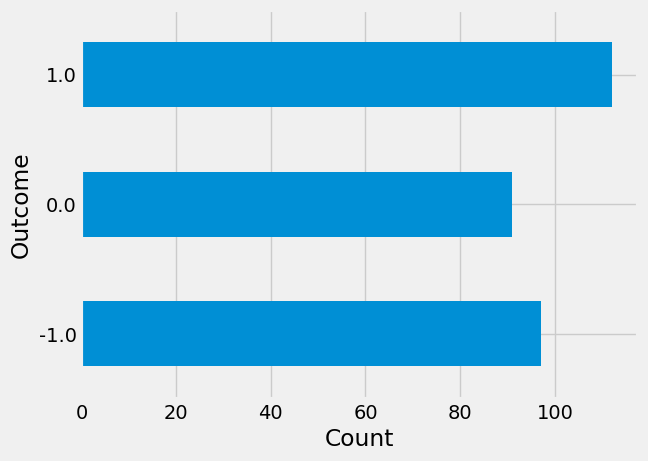

In [15]:
outcome_table = pd.DataFrame({'Outcome': outcomes})
outcome_counts = outcome_table['Outcome'].value_counts().sort_index()
outcome_counts.plot.barh()
plt.xlabel('Count')
plt.ylabel('Outcome')
plt.show()

Not surprisingly, each of the three outcomes (-1, 0, and 1) appears roughly 100 times out of 300, give or take. We will examine the variation in these counts more carefully in later chapters.